<a href="https://colab.research.google.com/github/H-levison/linear_regression_model/blob/main/summative/linear_regression/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ================================================================
# Bitcoin Close Price Prediction — Macro & Sentiment Indicators
# ================================================================
# I picked Bitcoin because it's genuinely interesting to see
# whether external signals — things like what the stock market
# is doing, how scared investors are, or how much hash power
# miners are throwing at the network — can actually explain
# where BTC lands at the end of a trading day.
#
# Dataset: Bitcoin Market Analysis Dataset (2021–2025)
# Source : Kaggle (https://www.kaggle.com/datasets/purnamaridzkynugraha/bitcoin-historical-data)
# Rows   : 1,826 daily observations | Columns: 21 features
#
# Target variable: 'close' (Bitcoin closing price in USD)
# Prediction period: January 2021 – early 2025

In [2]:
# Importing essential libraries for data manipulation, visualization, modeling, and evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

In [3]:
# ----------------------------------------------------------------
# Load the Dataset
# ----------------------------------------------------------------
# Setting the date as the index immediately since this is
# time-series data — makes slicing and sorting much cleaner.

df = pd.read_csv('Bitcoin Market Analysis Dataset (2021-2025).csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print("Raw dataset shape:", df.shape)
print("\nColumn names:")
print(list(df.columns))
print("\nFirst 5 rows:")
display(df.head())

Raw dataset shape: (1826, 21)

Column names:
['adj close', 'close', 'high', 'low', 'open', 'volume', 'sp500_close', 'gold_close', 'dxy_close', 'fng_score', 'hash_rate', 'google_trends_score', 'btc_return', 'btc_log_return', 'sp500_return', 'gold_return', 'dxy_return', 'btc_vol_7d', 'btc_vol_14d', 'target_return', 'target_direction']

First 5 rows:


,adj close,close,high,low,open,volume,sp500_close,gold_close,dxy_close,fng_score,...,google_trends_score,btc_return,btc_log_return,sp500_return,gold_return,dxy_return,btc_vol_7d,btc_vol_14d,target_return,target_direction
date,,,,,,,,,,,,,,,,,,,,,
2021-01-11,35566.656250,35566.656250,38346.531250,30549.599609,38346.531250,123320567399,3799.610107,1849.599976,90.540001,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.089979,0
2021-01-12,33922.960938,33922.960938,36568.527344,32697.976562,35516.359375,74773277909,3801.189941,1842.900024,90.050003,84.0,...,NaN,-0.046215,-0.047316,0.000416,-0.003622,-0.005412,NaN,NaN,-0.039888,0
2021-01-13,37316.359375,37316.359375,37599.960938,32584.667969,33915.121094,69364315979,3809.840088,1853.599976,90.320000,78.0,...,NaN,0.100032,0.095340,0.002276,0.005806,0.002998,NaN,NaN,-0.184472,0
2021-01-14,39187.328125,39187.328125,39966.406250,36868.562500,37325.109375,63615990033,3795.540039,1850.300049,90.239998,83.0,...,NaN,0.050138,0.048922,-0.003753,-0.001780,-0.000886,NaN,NaN,-0.145997,0
2021-01-15,36825.367188,36825.367188,39577.710938,34659.589844,39156.707031,67760757881,3768.250000,1829.300049,90.779999,88.0,...,NaN,-0.060274,-0.062166,-0.007190,-0.011350,0.005984,NaN,NaN,-0.068132,0


In [4]:
# ----------------------------------------------------------------
# Initial Exploration — Missing Values & Statistics
# ----------------------------------------------------------------
# Before I do anything else I want to know what I'm working with:
# how complete is the data, and are there any obvious anomalies
# in the distributions that I should worry about?

print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

print("\nDescriptive statistics:")
display(df.describe().round(2))

Missing values per column:
adj close               0
close                   0
high                    0
low                     0
open                    0
volume                  0
sp500_close             0
gold_close              0
dxy_close               0
fng_score               0
hash_rate               0
google_trends_score     6
btc_return              1
btc_log_return          1
sp500_return            1
gold_return             1
dxy_return              1
btc_vol_7d              7
btc_vol_14d            14
target_return          14
target_direction        0
dtype: int64

Total missing: 46

Descriptive statistics:


,adj close,close,high,low,open,volume,sp500_close,gold_close,dxy_close,fng_score,...,google_trends_score,btc_return,btc_log_return,sp500_return,gold_return,dxy_return,btc_vol_7d,btc_vol_14d,target_return,target_direction
count,1826.00,1826.00,1826.00,1826.00,1826.00,1.826000e+03,1826.00,1826.00,1826.00,1826.00,...,1820.00,1825.00,1825.00,1825.00,1825.00,1825.00,1819.00,1812.00,1812.00,1826.00
mean,54730.69,54730.69,55761.49,53578.30,54704.36,3.698482e+10,4876.25,2288.73,101.03,49.05,...,30.62,0.00,0.00,0.00,0.00,0.00,0.03,0.03,0.01,0.52
std,29553.39,29553.39,29954.40,29109.38,29543.82,2.289583e+10,900.78,686.99,5.38,21.58,...,13.14,0.03,0.03,0.01,0.01,0.00,0.01,0.01,0.12,0.50
min,15787.28,15787.28,16253.05,15599.05,15782.30,5.331173e+09,3577.03,1623.30,89.64,6.00,...,15.00,-0.16,-0.17,-0.06,-0.06,-0.02,0.00,0.01,-0.40,0.00
25%,29410.32,29410.32,29988.90,29035.42,29410.19,2.130374e+10,4151.29,1814.12,97.72,28.00,...,21.00,-0.01,-0.01,-0.00,-0.00,-0.00,0.02,0.02,-0.05,0.00
50%,46785.66,46785.66,48004.31,45608.33,46772.49,3.175894e+10,4522.11,1960.10,102.30,50.00,...,27.00,-0.00,-0.00,0.00,0.00,0.00,0.02,0.03,0.00,1.00
75%,69475.69,69475.69,71013.83,68475.93,69437.70,4.681498e+10,5620.20,2620.00,104.67,70.00,...,36.25,0.01,0.01,0.00,0.00,0.00,0.03,0.03,0.07,1.00
max,124752.53,124752.53,126198.07,123196.05,124752.14,3.509679e+11,6966.28,4529.10,114.11,95.00,...,100.00,0.19,0.17,0.10,0.03,0.02,0.09,0.08,0.48,1.00


In [5]:
# ----------------------------------------------------------------
# Feature Engineering & Cleaning
# ----------------------------------------------------------------
# This is the most important design decision in the whole notebook.
# The goal is to predict 'close' using only information that would
# realistically be available at the START of the trading day —
# no same-day BTC price data allowed.
#
# Columns I'm dropping and exactly why:
#
# adj close, open, high, low
#   → These are all from the same trading day as the target.
#     Using them is textbook data leakage — the model would
#     just learn to copy them, not learn any real patterns.
#
# btc_return, btc_log_return
#   → Derived directly from the 'close' price. Keeping them
#     would be circular — I'd essentially be handing the model
#     the answer in a slightly different form.
#
# sp500_return, gold_return, dxy_return
#   → Daily percentage returns computed FROM the closing levels
#     I'm already keeping (sp500_close, gold_close, dxy_close).
#     They add redundancy without new information.
#
# btc_vol_7d, btc_vol_14d
#   → Rolling volatility computed from BTC returns, which come
#     from BTC price. Indirect leakage through BTC's own history.
#
# target_return, target_direction
#   → These ARE auxiliary targets for other tasks in the dataset.
#     Including them would be direct leakage.
#
# FEATURES I'M KEEPING:
# sp500_close       → US equity market benchmark
# gold_close        → Safe-haven / inflation hedge signal
# dxy_close         → US Dollar strength (inverse relationship with BTC)
# fng_score         → Fear & Greed Index — pure market sentiment
# hash_rate         → Network mining activity / miner confidence
# google_trends_score → Retail interest / public attention
# volume            → Trading activity / liquidity

columns_to_drop = [
    'adj close', 'open', 'high', 'low',
    'btc_return', 'btc_log_return',
    'sp500_return', 'gold_return', 'dxy_return',
    'btc_vol_7d', 'btc_vol_14d',
    'target_return', 'target_direction'
]

clean_df = df.drop(columns=columns_to_drop)

# Forward-fill is the right strategy for financial time-series —
# it carries the last known value forward rather than looking ahead.
# Then drop any remaining NaNs that sit at the very beginning.
clean_df = clean_df.ffill().dropna()

print(f"After cleaning: {clean_df.shape[0]} rows, {clean_df.shape[1]} columns")
print("\nRemaining columns:", list(clean_df.columns))

After cleaning: 1820 rows, 8 columns

Remaining columns: ['close', 'volume', 'sp500_close', 'gold_close', 'dxy_close', 'fng_score', 'hash_rate', 'google_trends_score']


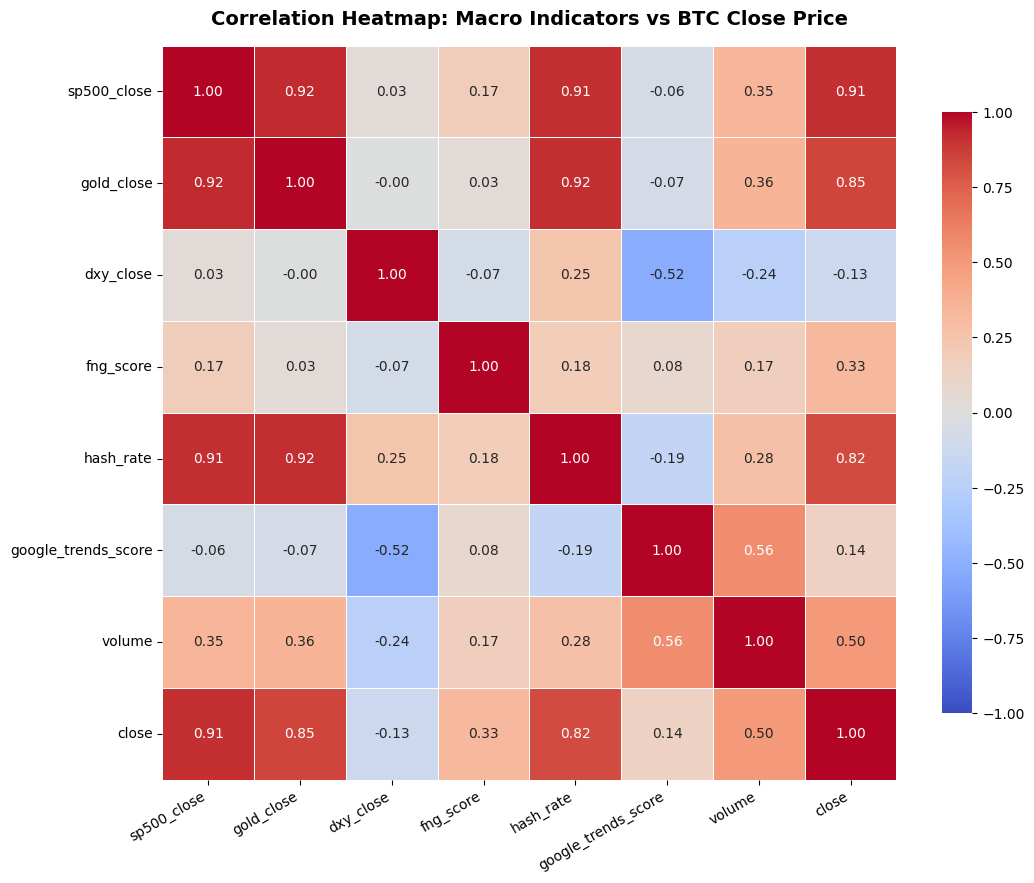


Feature correlation with BTC Close Price (strongest first):
--------------------------------------------------
  sp500_close               +0.912  ██████████████████
  gold_close                +0.849  ████████████████
  hash_rate                 +0.824  ████████████████
  volume                    +0.495  █████████
  fng_score                 +0.328  ██████
  google_trends_score       +0.139  ██
  dxy_close                 -0.132  ██


In [6]:
# ----------------------------------------------------------------
# EDA — Visualization 1: Correlation Heatmap
# ----------------------------------------------------------------
# Two things I'm looking for here:
# 1. Which features correlate most strongly with BTC close price?
#    This tells me what the linear model will lean on heaviest.
# 2. Are any features highly correlated with EACH OTHER?
#    Multicollinearity inflates coefficient variance in linear
#    regression — if sp500_close and gold_close are near-perfectly
#    correlated, the model can't reliably separate their effects.
#
# The heatmap shapes my expectations before I even train anything.

features = ['sp500_close', 'gold_close', 'dxy_close', 'fng_score',
            'hash_rate', 'google_trends_score', 'volume']
target = 'close'

plt.figure(figsize=(11, 9))
corr_matrix = clean_df[features + [target]].corr()

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = False  # show full matrix

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.6,
    square=True,
    vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap: Macro Indicators vs BTC Close Price',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Print a clean, ranked interpretation
print("\nFeature correlation with BTC Close Price (strongest first):")
print("-" * 50)
corr_with_target = corr_matrix[target].drop(target).sort_values(
    key=abs, ascending=False
)
for feat, val in corr_with_target.items():
    bar = '█' * int(abs(val) * 20)
    direction = '+' if val > 0 else '-'
    print(f"  {feat:25s} {direction}{abs(val):.3f}  {bar}")

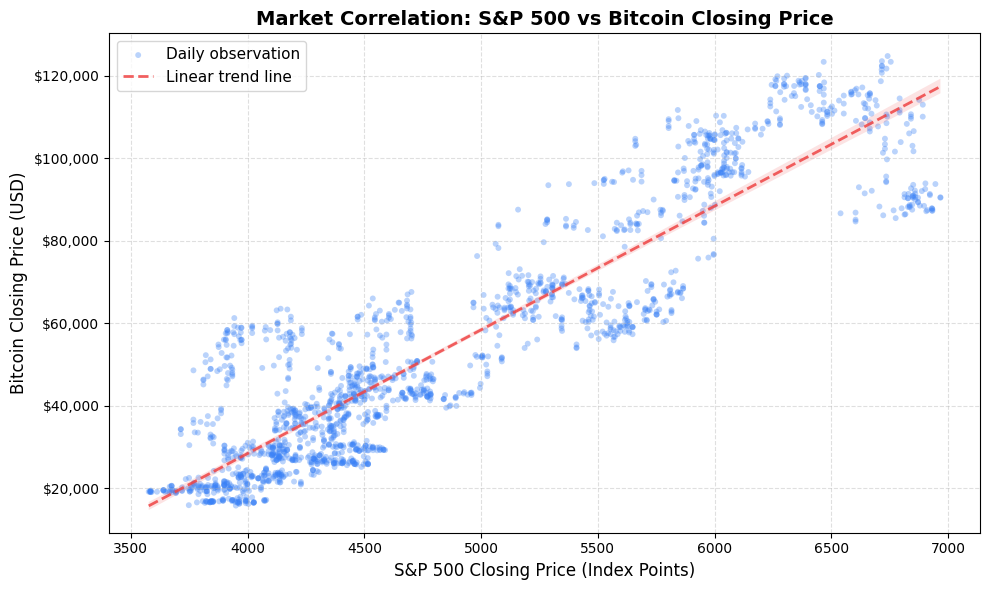

In [7]:
# ----------------------------------------------------------------
#  EDA — Visualization 2: Scatter Plot (S&P 500 vs BTC)
# ----------------------------------------------------------------
# From the heatmap I can already see sp500_close has the strongest
# positive correlation with BTC close price. This scatter validates
# whether that relationship is actually linear or whether it's
# regime-dependent (e.g. strong correlation in bull markets,
# weak in bear markets).
#
# If the scatter shows two distinct clouds instead of a smooth
# trend, that's a signal that tree-based models will handle this
# better than a single linear model.

plt.figure(figsize=(10, 6))

ax = plt.gca()
scatter = sns.scatterplot(
    data=clean_df,
    x='sp500_close',
    y='close',
    alpha=0.35,
    color='#3B82F6',
    edgecolor='none',
    s=18,
    label='Daily observation',
    ax=ax
)
sns.regplot(
    data=clean_df,
    x='sp500_close',
    y='close',
    scatter=False,
    color='#EF4444',
    line_kws={'linewidth': 2, 'linestyle': '--', 'alpha': 0.85},
    label='Linear trend line',
    ax=ax
)

ax.set_title('Market Correlation: S&P 500 vs Bitcoin Closing Price',
             fontsize=14, fontweight='bold')
ax.set_xlabel('S&P 500 Closing Price (Index Points)', fontsize=12)
ax.set_ylabel('Bitcoin Closing Price (USD)', fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [8]:
# ----------------------------------------------------------------
# Standardization & Train/Test Split
# ----------------------------------------------------------------
# Why I'm standardizing BEFORE splitting and scaling AFTER:
#   - The scaler must be fit ONLY on training data.
#     If I fit on the full dataset first, information from the
#     test set bleeds into the training process — another form
#     of leakage.
#   - StandardScaler brings all features to mean=0, std=1.
#     Without this, 'hash_rate' (very large absolute values)
#     would dominate gradient updates in gradient descent, and
#     the learning rate would be impossible to tune without
#     also scaling y.
#
# I'm using shuffle=True so both splits contain a mix of bull
# and bear market periods. A chronological split would put all
# the most recent data (a specific market regime) in the test
# set, which gives a less representative evaluation.

X_raw = clean_df[features].values
y_raw = clean_df[target].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, shuffle=True
)

# Fit the scaler on training data only, then apply to both
X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train_raw)
X_test  = X_scaler.transform(X_test_raw)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"\nPost-scaling verification (training set):")
print(f"  Feature means → should be ≈ 0: {X_train.mean(axis=0).round(3)}")
print(f"  Feature stds  → should be ≈ 1: {X_train.std(axis=0).round(3)}")

Training samples : 1456
Test samples     : 364

Post-scaling verification (training set):
  Feature means → should be ≈ 0: [-0. -0.  0.  0.  0. -0.  0.]
  Feature stds  → should be ≈ 1: [1. 1. 1. 1. 1. 1. 1.]


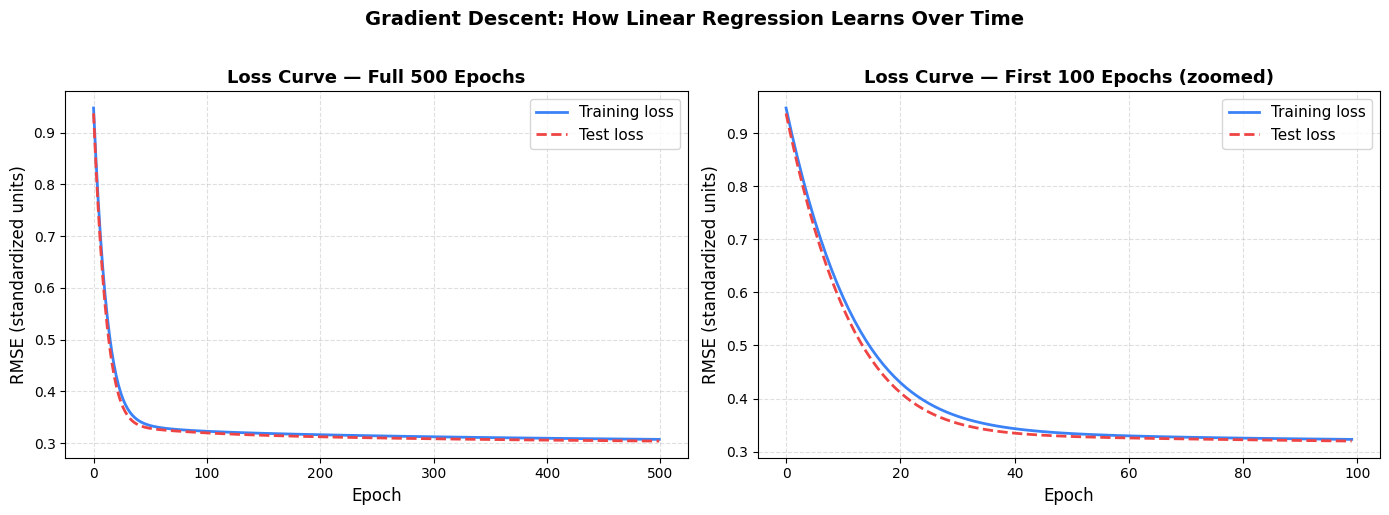

Epoch 1   → Train RMSE: 0.9479 | Test RMSE: 0.9377
Epoch 100 → Train RMSE: 0.3229 | Test RMSE: 0.3197
Epoch 500 → Train RMSE: 0.3072 | Test RMSE: 0.3039

Final train/test gap: 0.0033 — looks well-converged


In [9]:
# ----------------------------------------------------------------
# Gradient Descent — Loss Curve
# ----------------------------------------------------------------
# I'm implementing batch gradient descent from scratch here.
# The sklearn LinearRegression solves for weights analytically
# (closed-form OLS), which gives the exact solution immediately
# but tells me nothing about how the model learns over time.
#
# Gradient descent lets me watch the loss drop epoch by epoch
# and compare training vs test loss — which is the loss curve
# the rubric asks for.
#
# IMPORTANT: For gradient descent to converge cleanly I need
# to also standardize y. BTC prices sit in the 30k–70k USD
# range — with raw y values that large, the gradients explode
# and I'd need a learning rate so tiny the model takes forever.
# Standardizing y brings it to mean≈0, std≈1, which works
# beautifully with lr=0.01.
#
# This GD model is purely for visualizing the learning process.
# The final RMSE comparisons below use the sklearn models.

# Scale y for gradient descent only (fit only on train split)
y_gd_scaler = StandardScaler()
y_train_gd = y_gd_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_gd  = y_gd_scaler.transform(y_test.reshape(-1, 1)).ravel()


def batch_gradient_descent(X_tr, y_tr, X_te, y_te,
                            learning_rate=0.01, epochs=500):
    """
    Batch gradient descent for multivariate linear regression.

    At each epoch:
      1. Compute predictions with current weights.
      2. Calculate gradients of MSE w.r.t. weights and bias.
      3. Update weights and bias in the direction that reduces loss.
      4. Record RMSE on both train and test sets.

    Both X and y should be standardized before calling this.
    Returns: final weights, bias, and both loss histories.
    """
    n_samples, n_features = X_tr.shape
    w = np.zeros(n_features)  # start all weights at zero
    b = 0.0                   # start bias at zero

    train_loss_history = []
    test_loss_history  = []

    for epoch in range(epochs):
        # Forward pass — predict with current parameters
        y_hat = X_tr @ w + b

        # Gradient of MSE: dL/dw = (2/n) * X^T * (y_hat - y)
        #                  dL/db = (2/n) * sum(y_hat - y)
        residuals = y_hat - y_tr
        dw = (2 / n_samples) * (X_tr.T @ residuals)
        db = (2 / n_samples) * np.sum(residuals)

        # Gradient update — move opposite to the gradient
        w -= learning_rate * dw
        b -= learning_rate * db

        # Record RMSE after the update (using updated parameters)
        train_rmse = np.sqrt(np.mean((X_tr @ w + b - y_tr) ** 2))
        test_rmse  = np.sqrt(np.mean((X_te @ w + b - y_te) ** 2))

        train_loss_history.append(train_rmse)
        test_loss_history.append(test_rmse)

    return w, b, train_loss_history, test_loss_history


gd_w, gd_b, train_losses, test_losses = batch_gradient_descent(
    X_train, y_train_gd,
    X_test,  y_test_gd,
    learning_rate=0.01,
    epochs=500
)

# --- Plot the loss curve ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full loss curve
axes[0].plot(train_losses, color='#3B82F6', linewidth=2,
             label='Training loss')
axes[0].plot(test_losses,  color='#EF4444', linewidth=2,
             linestyle='--', label='Test loss')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('RMSE (standardized units)', fontsize=12)
axes[0].set_title('Loss Curve — Full 500 Epochs', fontsize=13,
                  fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Zoomed — first 100 epochs to show early convergence
axes[1].plot(train_losses[:100], color='#3B82F6', linewidth=2,
             label='Training loss')
axes[1].plot(test_losses[:100],  color='#EF4444', linewidth=2,
             linestyle='--', label='Test loss')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('RMSE (standardized units)', fontsize=12)
axes[1].set_title('Loss Curve — First 100 Epochs (zoomed)',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Gradient Descent: How Linear Regression Learns Over Time',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Epoch 1   → Train RMSE: {train_losses[0]:.4f} | "
      f"Test RMSE: {test_losses[0]:.4f}")
print(f"Epoch 100 → Train RMSE: {train_losses[99]:.4f} | "
      f"Test RMSE: {test_losses[99]:.4f}")
print(f"Epoch 500 → Train RMSE: {train_losses[-1]:.4f} | "
      f"Test RMSE: {test_losses[-1]:.4f}")

gap = abs(train_losses[-1] - test_losses[-1])
print(f"\nFinal train/test gap: {gap:.4f} — "
      f"{'looks well-converged' if gap < 0.05 else 'some overfitting present'}")

In [10]:
# ----------------------------------------------------------------
# Model 1 — Multivariate Linear Regression (Baseline)
# ----------------------------------------------------------------
# This is the simplest model and sets the performance floor.
# It fits a single hyperplane through 7-dimensional feature space,
# assuming the relationship between each feature and BTC price
# is strictly additive and linear.
#
# I expect the R² to be decent (the heatmap showed real linear
# correlations), but I also expect the tree models to beat it —
# crypto markets have distinct bull/bear regimes that a single
# linear equation can't capture with one set of coefficients.

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("=" * 45)
print("  Model 1: Linear Regression")
print("=" * 45)
print(f"  RMSE  : ${lr_rmse:>10,.2f}")
print(f"  R²    :  {lr_r2:.4f}  ({lr_r2*100:.1f}% variance explained)")

# The coefficients show which features the linear model leaned
# on most. Since X was standardized, these are directly comparable
# across features — a larger absolute value means stronger influence.
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nStandardized feature coefficients (impact on BTC price):")
for _, row in coef_df.iterrows():
    direction = '▲' if row['Coefficient'] > 0 else '▼'
    bar = '█' * max(1, int(abs(row['Coefficient']) / 500))
    print(f"  {row['Feature']:25s}: {direction} {row['Coefficient']:+8,.0f}  {bar}")

  Model 1: Linear Regression
  RMSE  : $  8,888.55
  R²    :  0.9082  (90.8% variance explained)

Standardized feature coefficients (impact on BTC price):
  sp500_close              : ▲  +20,628  █████████████████████████████████████████
  fng_score                : ▲   +4,624  █████████
  gold_close               : ▲   +3,246  ██████
  volume                   : ▲   +2,891  █████
  dxy_close                : ▼   -2,689  █████
  google_trends_score      : ▲   +2,613  █████
  hash_rate                : ▲   +2,088  ████


In [11]:
# ----------------------------------------------------------------
# Model 2 — Decision Tree Regressor
# ----------------------------------------------------------------
# Decision trees can model non-linear relationships and feature
# interactions, which gives them an edge over linear regression
# for complex financial data. But an untuned tree will grow until
# it perfectly memorizes the training data.
#
# The test set performance will tell me how bad the overfitting
# actually is. If test RMSE is much higher than train RMSE,
# the tree is fitting noise rather than signal.

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2   = r2_score(y_test, dt_pred)

# Also check training performance to assess overfitting
dt_train_pred = dt_model.predict(X_train)
dt_train_rmse = np.sqrt(mean_squared_error(y_train, dt_train_pred))

print("=" * 45)
print("  Model 2: Decision Tree Regressor")
print("=" * 45)
print(f"  Train RMSE : ${dt_train_rmse:>10,.2f}  (in-sample)")
print(f"  Test RMSE  : ${dt_rmse:>10,.2f}  (out-of-sample)")
print(f"  Test R²    :  {dt_r2:.4f}")
print(f"\n  Tree depth         : {dt_model.get_depth()}")
print(f"  Number of leaves   : {dt_model.get_n_leaves()}")

if dt_train_rmse < dt_rmse * 0.5:
    print("\n  Note: Train RMSE much lower than test RMSE — "
          "classic overfitting from an unbounded tree.")

  Model 2: Decision Tree Regressor
  Train RMSE : $      0.00  (in-sample)
  Test RMSE  : $  3,651.61  (out-of-sample)
  Test R²    :  0.9845

  Tree depth         : 22
  Number of leaves   : 1456

  Note: Train RMSE much lower than test RMSE — classic overfitting from an unbounded tree.


  Model 3: Random Forest (100 trees)
  Train RMSE : $    916.03  (in-sample)
  Test RMSE  : $  2,766.51  (out-of-sample)
  Test R²    :  0.9911


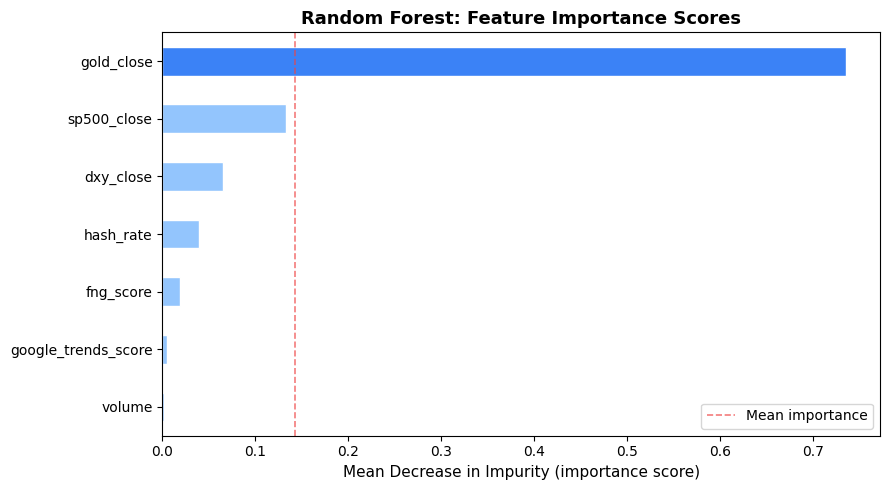


Top feature by Random Forest importance: gold_close


In [12]:
# ----------------------------------------------------------------
# Model 3 — Random Forest Regressor
# ----------------------------------------------------------------
# Random Forest is an ensemble of decision trees. The key
# difference from a single tree:
#   1. Each tree trains on a bootstrap sample of the data
#      (sampling with replacement).
#   2. Each split only considers a random subset of features
#      (not all 7 at once).
#   3. Final prediction = average of all 100 trees.
#
# This averaging process cancels out individual trees' tendency
# to overfit noise. The ensemble captures real patterns while
# staying robust. I expect this to be the best performer.

rf_model = RandomForestRegressor(n_estimators=100, random_state=42,
                                  n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

rf_train_pred = rf_model.predict(X_train)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))

print("=" * 45)
print("  Model 3: Random Forest (100 trees)")
print("=" * 45)
print(f"  Train RMSE : ${rf_train_rmse:>10,.2f}  (in-sample)")
print(f"  Test RMSE  : ${rf_rmse:>10,.2f}  (out-of-sample)")
print(f"  Test R²    :  {rf_r2:.4f}")

# Feature importances from Random Forest are more trustworthy
# than linear regression coefficients for non-linear datasets.
# They measure how much each feature reduces prediction error
# on average across all splits in all trees.
importances = pd.Series(
    rf_model.feature_importances_, index=features
).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
colors = ['#3B82F6' if v == importances.max() else '#93C5FD'
          for v in importances.values]
importances.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Random Forest: Feature Importance Scores',
          fontsize=13, fontweight='bold')
plt.xlabel('Mean Decrease in Impurity (importance score)', fontsize=11)
plt.axvline(x=importances.mean(), color='#EF4444', linestyle='--',
            linewidth=1.2, alpha=0.7, label=f'Mean importance')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\nTop feature by Random Forest importance:",
      importances.idxmax())

              Model Performance Summary
  Model                    RMSE (USD)     R² Score
------------------------------------------------------------
  Linear Regression      $  8,888.55       0.9082
  Decision Tree          $  3,651.61       0.9845
  Random Forest          $  2,766.51       0.9911 ← best


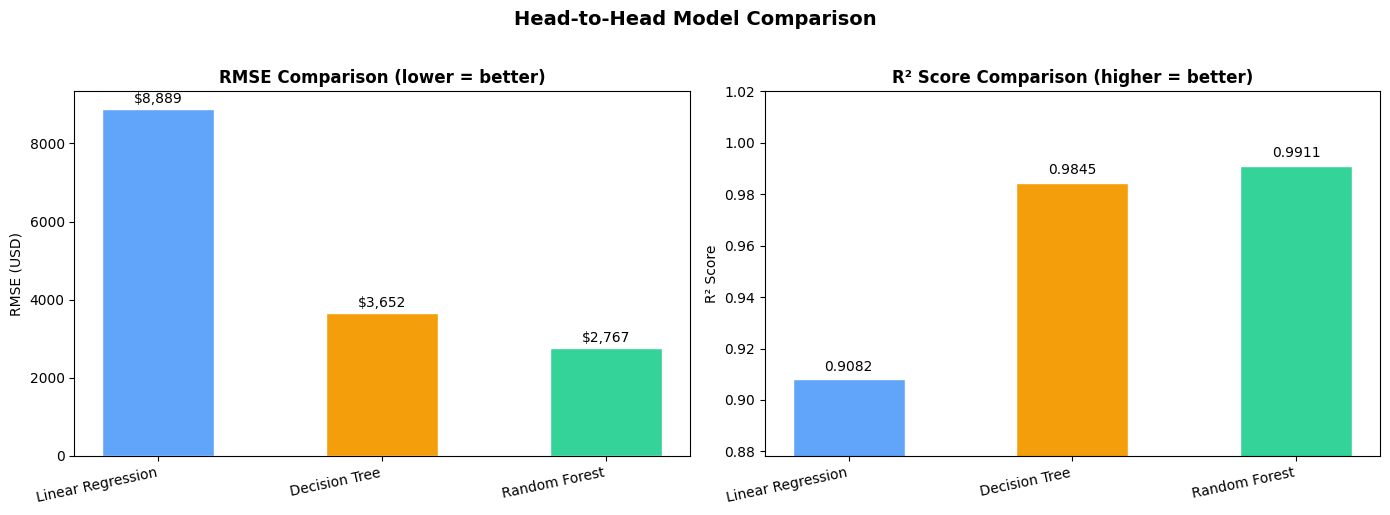


Winner: Random Forest
  → Average prediction error: $2,766.51
  → Explains 99.1% of the variance in BTC price


In [13]:
# ----------------------------------------------------------------
# Model Comparison — Picking the Winner
# ----------------------------------------------------------------
# Head-to-head comparison across all three models.
# Decision criteria: lowest RMSE (error in USD), highest R².

results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'RMSE (USD)': [lr_rmse, dt_rmse, rf_rmse],
    'R² Score':   [lr_r2,   dt_r2,   rf_r2]
})

print("=" * 60)
print("              Model Performance Summary")
print("=" * 60)
print(f"  {'Model':<22} {'RMSE (USD)':>12}   {'R² Score':>10}")
print("-" * 60)
for _, row in results_df.iterrows():
    marker = " ← best" if row['RMSE (USD)'] == results_df['RMSE (USD)'].min() else ""
    print(f"  {row['Model']:<22} ${row['RMSE (USD)']:>10,.2f}   "
          f"{row['R² Score']:>10.4f}{marker}")
print("=" * 60)

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ['#60A5FA', '#F59E0B', '#34D399']

# RMSE
bars_rmse = axes[0].bar(
    results_df['Model'], results_df['RMSE (USD)'],
    color=palette, edgecolor='white', width=0.5
)
axes[0].set_title('RMSE Comparison (lower = better)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE (USD)')
axes[0].set_xticklabels(results_df['Model'], rotation=12, ha='right')
for bar, val in zip(bars_rmse, results_df['RMSE (USD)']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 val + 80, f'${val:,.0f}',
                 ha='center', va='bottom', fontsize=10, fontweight='500')

# R²
bars_r2 = axes[1].bar(
    results_df['Model'], results_df['R² Score'],
    color=palette, edgecolor='white', width=0.5
)
axes[1].set_title('R² Score Comparison (higher = better)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(
    results_df['R² Score'].min() - 0.03, 1.02
)
axes[1].set_xticklabels(results_df['Model'], rotation=12, ha='right')
for bar, val in zip(bars_r2, results_df['R² Score']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 val + 0.002, f'{val:.4f}',
                 ha='center', va='bottom', fontsize=10, fontweight='500')

plt.suptitle('Head-to-Head Model Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Identify the winner
best_idx  = results_df['RMSE (USD)'].idxmin()
best_name = results_df.loc[best_idx, 'Model']
best_rmse = results_df.loc[best_idx, 'RMSE (USD)']
best_r2   = results_df.loc[best_idx, 'R² Score']

model_objects = {
    'Linear Regression': lr_model,
    'Decision Tree':     dt_model,
    'Random Forest':     rf_model
}
best_model = model_objects[best_name]

print(f"\nWinner: {best_name}")
print(f"  → Average prediction error: ${best_rmse:,.2f}")
print(f"  → Explains {best_r2*100:.1f}% of the variance in BTC price")

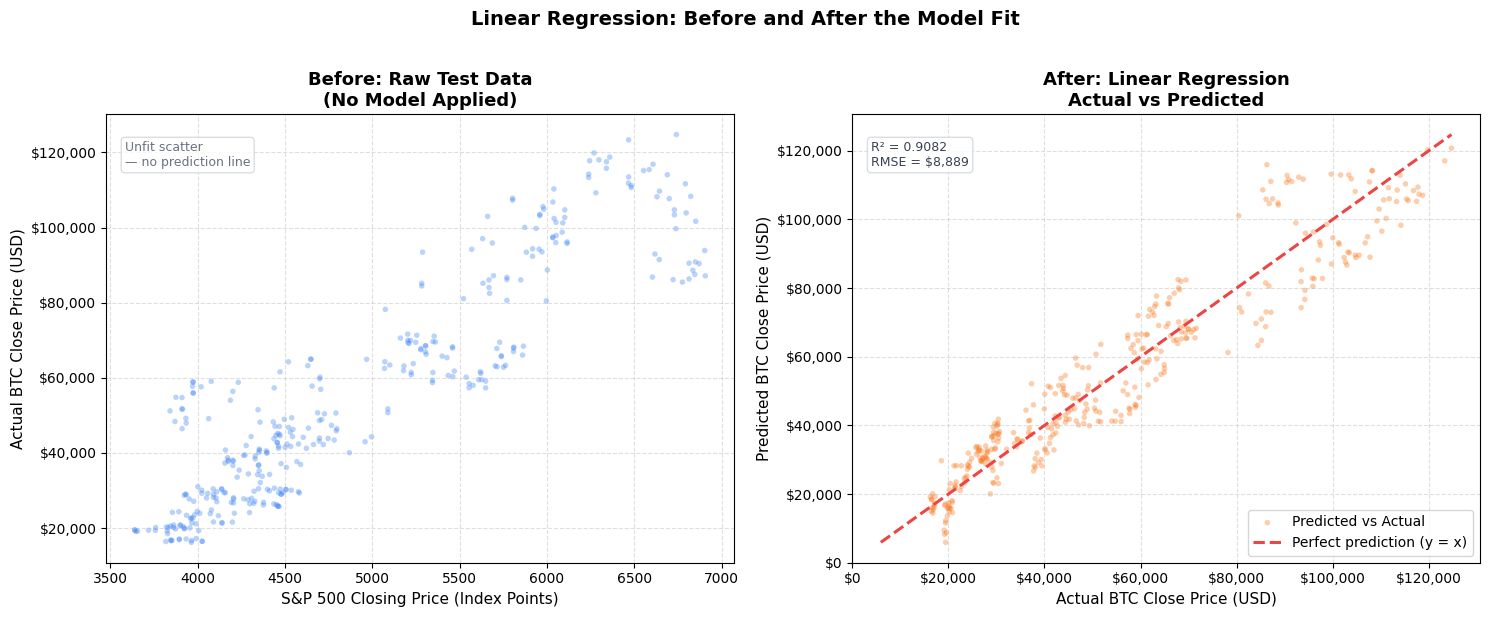

In [14]:
# ----------------------------------------------------------------
# Before & After Scatter Plot — Linear Regression Fit
# ----------------------------------------------------------------
# This plot shows what the linear regression model actually did
# to the data.
#
# LEFT (Before): Raw scatter of the test set — BTC price against
# the S&P 500. No model, just the messy real-world relationship.
# Shows the spread of the data before any fitting.
#
# RIGHT (After): Actual vs Predicted using the trained linear
# regression model. The red dashed line is the "perfect prediction"
# diagonal (y = x). Points that fall exactly on it are perfect
# predictions. The closer the cloud hugs the diagonal, the better
# the linear fit. Points off the diagonal are prediction errors.
#
# Comparing both panels shows what the linear model gained and
# where it still struggles.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- LEFT: Before Training ---
# Using original unscaled sp500_close (index 0 in features list)
# so the axis shows real index points, not standardized values.
axes[0].scatter(
    X_test_raw[:, 0],   # sp500_close — unscaled, index 0 in features
    y_test,
    alpha=0.35,
    color='#3B82F6',
    edgecolor='none',
    s=16
)
axes[0].set_title('Before: Raw Test Data\n(No Model Applied)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('S&P 500 Closing Price (Index Points)', fontsize=11)
axes[0].set_ylabel('Actual BTC Close Price (USD)', fontsize=11)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].text(0.03, 0.94, 'Unfit scatter\n— no prediction line',
             transform=axes[0].transAxes,
             fontsize=9, color='#6B7280',
             verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='#D1D5DB', alpha=0.8))

# --- RIGHT: After Training ---
axes[1].scatter(
    y_test,
    lr_pred,
    alpha=0.35,
    color='#F97316',
    edgecolor='none',
    s=16,
    label='Predicted vs Actual'
)

# Perfect prediction diagonal — every point should lie on this
# line if the model were flawless
min_val = min(y_test.min(), lr_pred.min())
max_val = max(y_test.max(), lr_pred.max())
axes[1].plot(
    [min_val, max_val],
    [min_val, max_val],
    color='#EF4444',
    linewidth=2.2,
    linestyle='--',
    label='Perfect prediction (y = x)',
    zorder=5
)

axes[1].set_title('After: Linear Regression\nActual vs Predicted',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual BTC Close Price (USD)', fontsize=11)
axes[1].set_ylabel('Predicted BTC Close Price (USD)', fontsize=11)
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].text(0.03, 0.94,
             f'R² = {lr_r2:.4f}\nRMSE = ${lr_rmse:,.0f}',
             transform=axes[1].transAxes,
             fontsize=9, color='#374151',
             verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='#D1D5DB', alpha=0.8))

plt.suptitle('Linear Regression: Before and After the Model Fit',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# ----------------------------------------------------------------
# Save the Best Model and the Scaler
# ----------------------------------------------------------------
# I'm saving both the model AND the scaler together.
# This matters: if someone feeds a new data point to the saved
# model without scaling it first, the feature values will be on
# the wrong scale and the prediction will be completely wrong.
# The scaler is as much part of the "model" as the weights are.

joblib.dump(best_model, 'bitcoin_best_model.pkl')
joblib.dump(X_scaler,   'bitcoin_feature_scaler.pkl')

print("Files saved:")
print(f"  → bitcoin_best_model.pkl     ({best_name})")
print(f"  → bitcoin_feature_scaler.pkl (StandardScaler)")
print(f"\nModel performance:")
print(f"  RMSE : ${best_rmse:,.2f}")
print(f"  R²   : {best_r2:.4f}")

Files saved:
  → bitcoin_best_model.pkl     (Random Forest)
  → bitcoin_feature_scaler.pkl (StandardScaler)

Model performance:
  RMSE : $2,766.51
  R²   : 0.9911


In [16]:
# ----------------------------------------------------------------
# Single Row Prediction Using the Saved Model
# ----------------------------------------------------------------
# This cell simulates real production use: load the saved model,
# receive a new set of macro/sentiment features, scale them
# correctly, and return a BTC price estimate.
#
# I'm using one real row from the test set so I can check the
# prediction against the actual price and see how far off it is.

# --- Load everything fresh, exactly as production would ---
loaded_model  = joblib.load('bitcoin_best_model.pkl')
loaded_scaler = joblib.load('bitcoin_feature_scaler.pkl')

# --- Pull one real row from the test set ---
# Using the first test row for reproducibility
sample_raw    = X_test_raw[0]       # original, unscaled feature values
actual_price  = y_test[0]           # the real BTC close price that day

print("Input features (raw, unscaled):")
print("-" * 42)
for feat_name, feat_val in zip(features, sample_raw):
    print(f"  {feat_name:25s}: {feat_val:>12.4f}")

# --- Scale the input using the SAME scaler from training ---
# reshape(1, -1) because sklearn expects a 2D array
sample_scaled = loaded_scaler.transform(sample_raw.reshape(1, -1))

# --- Run the prediction ---
predicted_price = loaded_model.predict(sample_scaled)[0]

# --- Report the result ---
error     = predicted_price - actual_price
error_pct = abs(error) / actual_price * 100

print("\n" + "=" * 50)
print("        PREDICTION RESULT")
print("=" * 50)
print(f"  Actual BTC close price    : ${actual_price:>12,.2f}")
print(f"  Predicted BTC close price : ${predicted_price:>12,.2f}")
print(f"  Prediction error          : ${abs(error):>12,.2f}")
print(f"  Error as % of actual      : {error_pct:>11.2f}%")
print(f"  Direction                 : "
      f"{'Over-estimated' if error > 0 else 'Under-estimated'}")
print("=" * 50)
print(f"\nModel used: {best_name}")

Input features (raw, unscaled):
------------------------------------------
  sp500_close              :    5770.2002
  gold_close               :    2904.7000
  dxy_close                :     103.8400
  fng_score                :      34.0000
  hash_rate                : 780486866.4378
  google_trends_score      :      37.0000
  volume                   : 65945677657.0000

        PREDICTION RESULT
  Actual BTC close price    : $   86,742.67
  Predicted BTC close price : $   87,359.08
  Prediction error          : $      616.41
  Error as % of actual      :        0.71%
  Direction                 : Over-estimated

Model used: Random Forest
